# 1.1 EDA

In [43]:
# Load training and test datasets
import pandas as pd

train = pd.read_csv('car_crash_train.csv')
test  = pd.read_csv('car_crash_test.csv')

In [3]:
# ── Basic dataset overview ──
print('=== First 5 rows ===')
display(train.head())

print('=== Data types & non-null counts ===')
train.info()

print('=== Descriptive statistics ===')
display(train.describe(include='all'))

print('=== Missing values per column ===')
display(train.isnull().sum().rename('missing'))

# Inspect target class distribution
print('=== Target class counts ===')
display(train['Severity'].value_counts())

print('=== Target class proportions ===')
display(train['Severity'].value_counts(normalize=True))

=== First 5 rows ===


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


=== Data types & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Lev

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
count,4000.000000,4000.000000,4000,4000,4000,4000,4000,4000,4000.000000,4000,4000,4000.000000,4000.000000,4000.000000,1640,4000,4000,4000.000000,4000
unique,NaN,NaN,2,2,4,4,4,4,NaN,2,2,NaN,NaN,NaN,3,3,3,NaN,3
top,NaN,NaN,Yes,Yes,Clear,Dry,Side impact,Sedan,NaN,Good,Good,NaN,NaN,NaN,Phone,Afternoon,Medium,NaN,Minor Injury
freq,NaN,NaN,2817,3174,2345,2792,1413,1644,NaN,3369,3225,NaN,NaN,NaN,773,1579,1979,NaN,2756
mean,110.999750,89.979750,NaN,NaN,NaN,NaN,NaN,NaN,9.445500,NaN,NaN,48.698750,24.723000,0.101216,NaN,NaN,NaN,247.583500,NaN
std,52.227839,51.301514,NaN,NaN,NaN,NaN,NaN,NaN,5.718147,NaN,NaN,17.815972,14.211818,0.057820,NaN,NaN,NaN,143.478155,NaN
min,20.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,18.000000,0.000000,0.000054,NaN,NaN,NaN,10.000000,NaN
25%,66.000000,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,34.000000,13.000000,0.050630,NaN,NaN,NaN,120.000000,NaN
50%,112.000000,89.500000,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,49.000000,25.000000,0.101574,NaN,NaN,NaN,244.000000,NaN
75%,157.000000,134.000000,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,NaN,NaN,64.000000,37.000000,0.151783,NaN,NaN,NaN,372.000000,NaN


=== Missing values per column ===


,missing
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


=== Target class counts ===


,count
Severity,
Minor Injury,2756
Severe Injury,1038
Fatal,206


=== Target class proportions ===


,proportion
Severity,
Minor Injury,0.6890
Severe Injury,0.2595
Fatal,0.0515


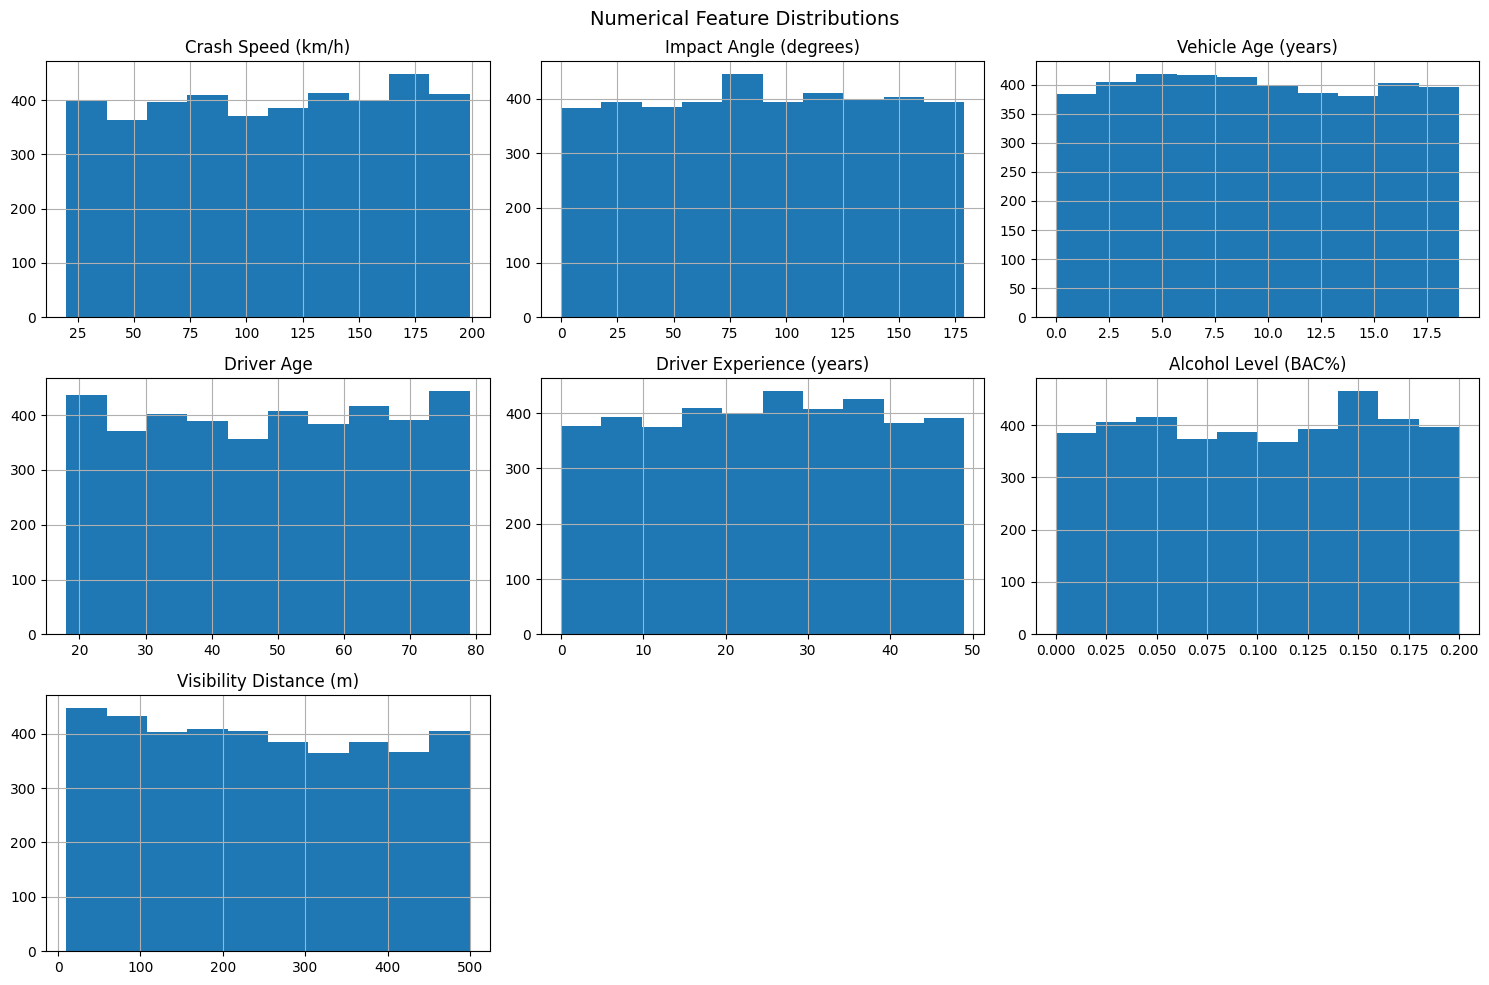

In [4]:
# ── Numerical feature distributions ──
# Histograms reveal skewness, outliers, and value ranges for each numeric column
import matplotlib.pyplot as plt

num_cols = train.select_dtypes(include=['int64', 'float64']).columns

train[num_cols].hist(figsize=(15, 10))
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

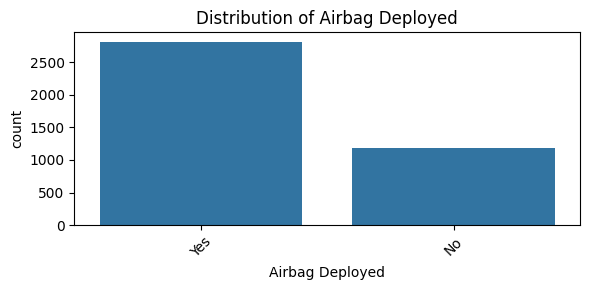

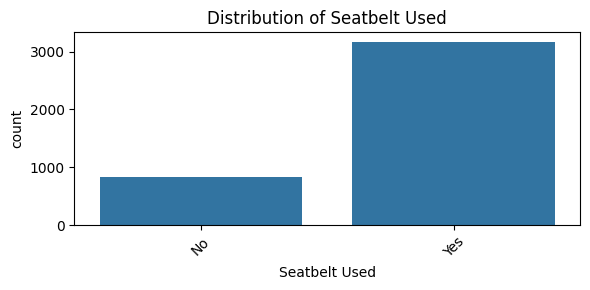

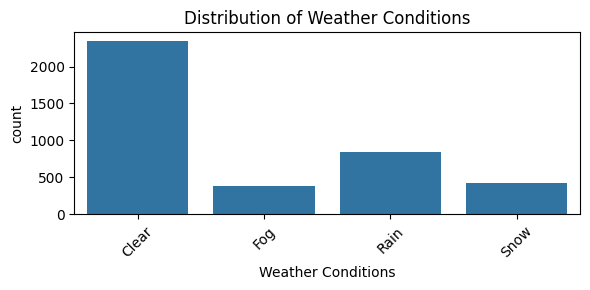

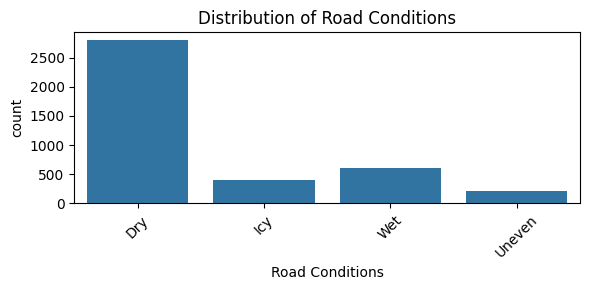

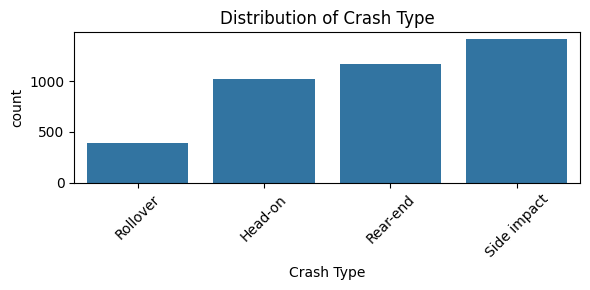

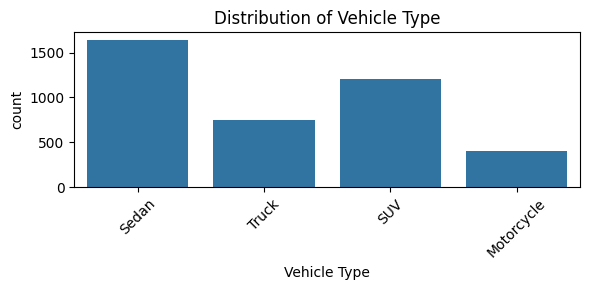

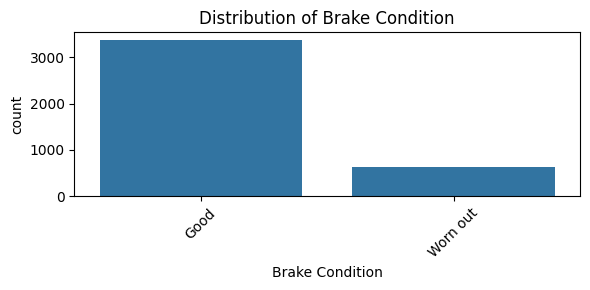

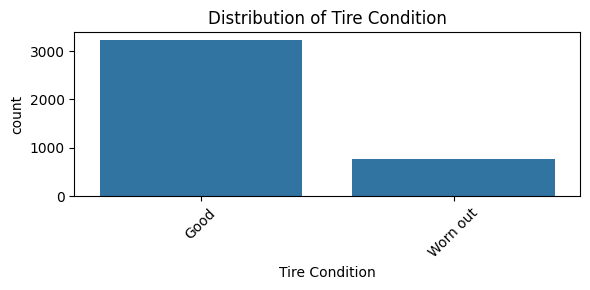

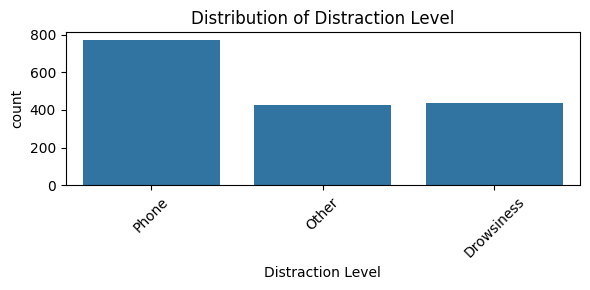

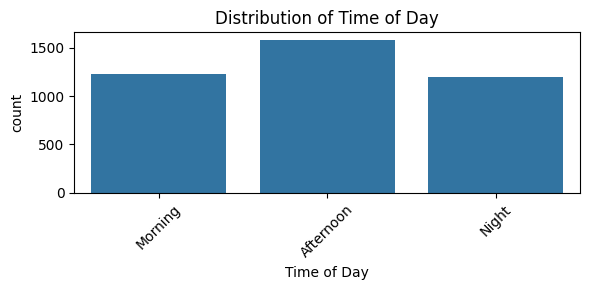

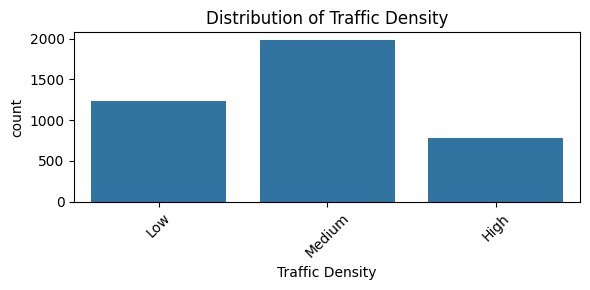

In [5]:
# ── Categorical feature distributions ──
# Count plots show class frequencies within each categorical variable
import seaborn as sns

cat_cols = train.select_dtypes(include='object').drop(columns='Severity').columns

for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, data=train)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

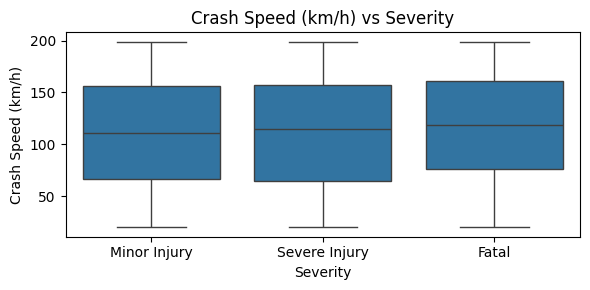

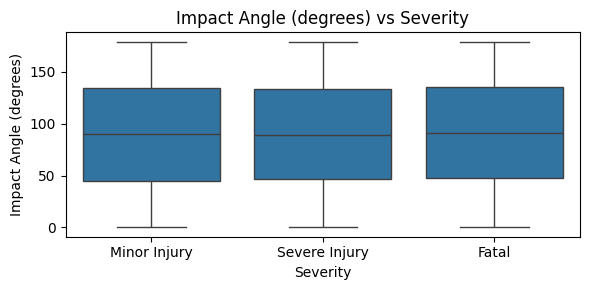

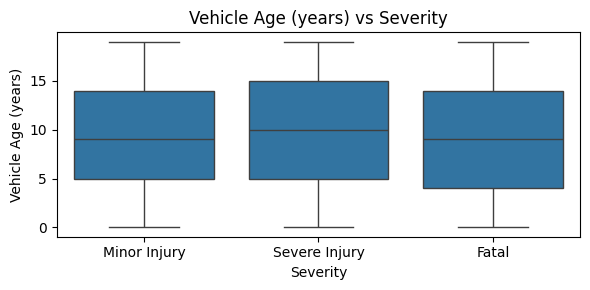

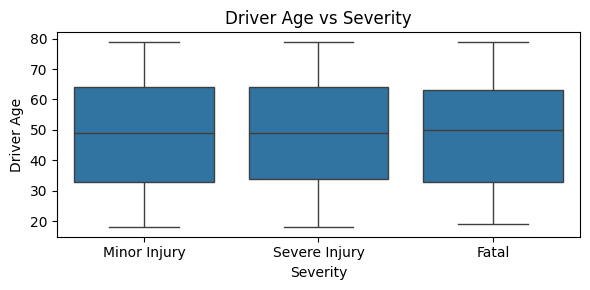

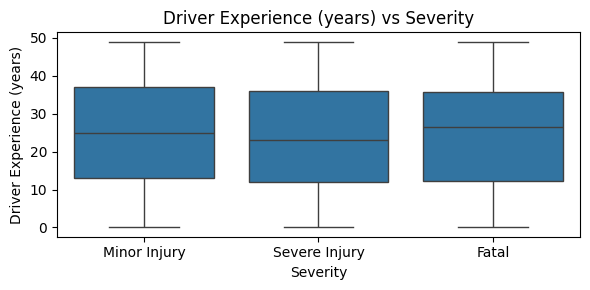

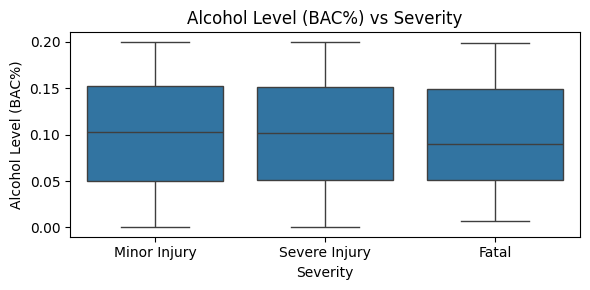

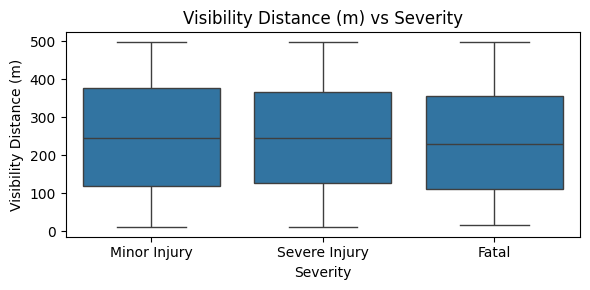


--- Airbag Deployed vs Severity ---
Severity         Fatal  Minor Injury  Severe Injury
Airbag Deployed                                    
No               0.053         0.691          0.256
Yes              0.051         0.688          0.261

--- Seatbelt Used vs Severity ---
Severity       Fatal  Minor Injury  Severe Injury
Seatbelt Used                                    
No             0.053         0.678          0.269
Yes            0.051         0.692          0.257

--- Weather Conditions vs Severity ---
Severity            Fatal  Minor Injury  Severe Injury
Weather Conditions                                    
Clear               0.053         0.690          0.257
Fog                 0.049         0.698          0.253
Rain                0.046         0.684          0.270
Snow                0.057         0.684          0.259

--- Road Conditions vs Severity ---
Severity         Fatal  Minor Injury  Severe Injury
Road Conditions                                    
Dry      

In [6]:
# ── Feature vs Target analysis ──
# Box plots reveal how numeric features vary across severity classes
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='Severity', y=col, data=train)
    plt.title(f'{col} vs Severity')
    plt.tight_layout()
    plt.show()

# Cross-tabulations show conditional distributions for categorical features
for col in cat_cols:
    print(f'\n--- {col} vs Severity ---')
    print(pd.crosstab(train[col], train['Severity'], normalize='index').round(3))

# 1.2 Preprocessing

In [7]:
# ── Handle missing values ──
train['Distraction Level'] = train['Distraction Level'].fillna('Unknown')
test['Distraction Level']  = test['Distraction Level'].fillna('Unknown')

In [8]:
# ── Separate features and target ──
X = train.drop('Severity', axis=1)
y = train['Severity']

In [9]:
# ── Encode target labels to integers ──
# LabelEncoder maps each severity class string to a unique integer
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y = le_target.fit_transform(y)
print('Classes:', le_target.classes_)

Classes: ['Fatal' 'Minor Injury' 'Severe Injury']


In [10]:
# ── One-hot encode categorical features ──
X    = pd.get_dummies(X,    drop_first=True)
test = pd.get_dummies(test, drop_first=True)

# Align ensures test has same columns as X (filling any missing cols with 0)
X, test = X.align(test, join='left', axis=1, fill_value=0)
print('Feature count after encoding:', X.shape[1])

Feature count after encoding: 30


In [11]:
# ── Standardise numerical features ──
# StandardScaler transforms each numeric column to zero mean and unit variance.
# This is critical for distance-based (KNN) and linear (Logistic Regression) models.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)',
            'Vehicle Age (years)', 'Driver Age',
            'Driver Experience (years)', 'Alcohol Level (BAC%)',
            'Visibility Distance (m)']

X[num_cols]    = scaler.fit_transform(X[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

In [12]:
# ── Handle class imbalance with SMOTE ──
# for minority classes so the classifier does not become biased toward the majority class
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y  = smote.fit_resample(X, y)
print('Class distribution after SMOTE:', pd.Series(y).value_counts().to_dict())

Class distribution after SMOTE: {1: 2756, 2: 2756, 0: 2756}


In [13]:
# ── Feature engineering ──
# Risk Score: combines speed and alcohol level; both are known crash-severity drivers
# Experience Ratio: captures relative driving experience relative to age;
#   a high ratio → more experienced for their age → potentially lower risk
X['Risk Score']       = X['Crash Speed (km/h)'] * X['Alcohol Level (BAC%)']
X['Experience Ratio'] = X['Driver Experience (years)'] / (X['Driver Age'] + 1)

# Apply the same derived features to the held-out test set
test['Risk Score']       = test['Crash Speed (km/h)'] * test['Alcohol Level (BAC%)']
test['Experience Ratio'] = test['Driver Experience (years)'] / (test['Driver Age'] + 1)

print('Final feature count:', X.shape[1])

Final feature count: 32


In [14]:
# ── Shared train / validation / test split (used by ALL models) ──
# 60 % train | 20 % validation | 20 % test
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f'Train size      : {len(X_train)}')
print(f'Validation size : {len(X_val)}')
print(f'Test size       : {len(X_test)}')

Train size      : 4960
Validation size : 1654
Test size       : 1654


# 2.1 KNN

In [15]:
# ── Hyperparameter tuning: find best K ──
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

k_values = range(3, 21)
f1_scores = []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    f1_scores.append(f1_score(y_val, knn_tmp.predict(X_val), average='weighted'))

best_k = k_values[np.argmax(f1_scores)]
print('Best K:', best_k)

Best K: 3


In [16]:
# ── Train the final KNN model with best K ──
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [17]:
# ── Evaluate KNN on validation set ──
# Weighted F1 is the primary metric as it accounts for class imbalance
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

y_pred_knn = knn.predict(X_val)

print('===== KNN VALIDATION PERFORMANCE =====')
print(f'Accuracy  : {accuracy_score(y_val, y_pred_knn):.4f}')
print(f'Precision : {precision_score(y_val, y_pred_knn, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_val, y_pred_knn, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_val, y_pred_knn, average="weighted"):.4f}')
print('\nDetailed Report:')
print(classification_report(y_val, y_pred_knn))

===== KNN VALIDATION PERFORMANCE =====
Accuracy  : 0.7346
Precision : 0.7341
Recall    : 0.7346
F1 Score  : 0.7204

Detailed Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85       552
           1       0.74      0.48      0.58       551
           2       0.70      0.75      0.73       551

    accuracy                           0.73      1654
   macro avg       0.73      0.73      0.72      1654
weighted avg       0.73      0.73      0.72      1654



In [18]:
# ── 5-fold Cross-Validation for KNN ──
# CV gives a more reliable estimate of generalisation performance
# by averaging results across 5 different train/val splits
from sklearn.model_selection import cross_val_score

cv_f1_knn = cross_val_score(KNeighborsClassifier(n_neighbors=best_k),
                            X, y, cv=5, scoring='f1_weighted')
print('===== KNN CROSS-VALIDATION =====')
print('F1 per fold :', cv_f1_knn.round(4))
print('Mean F1     :', cv_f1_knn.mean().round(4))

===== KNN CROSS-VALIDATION =====
F1 per fold : [0.7213 0.7301 0.7742 0.7422 0.7592]
Mean F1     : 0.7454


**KNN Summary:** The model was tuned by selecting the K that maximised weighted F1 on the validation set. Cross-validation was used to confirm that the result generalises across different data folds.

# 2.2 Decision Trees

In [19]:
# ── Baseline Decision Tree (no depth limit) ──
from sklearn.tree import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

print('--- Baseline Decision Tree ---')
print('Train Accuracy     :', f"{dt_base.score(X_train, y_train):.4f}")
print('Validation Accuracy:', f"{dt_base.score(X_val, y_val):.4f}")

--- Baseline Decision Tree ---
Train Accuracy     : 1.0000
Validation Accuracy: 0.6306


In [20]:
# ── Hyperparameter tuning with GridSearchCV ──
# max_depth limits tree height (prevents overfitting)
from sklearn.model_selection import GridSearchCV

params_dt = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       params_dt, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print('Best params :', grid_dt.best_params_)
print('Best CV F1  :', round(grid_dt.best_score_, 4))

Best params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1  : 0.6188


In [21]:
# ── Evaluate the tuned Decision Tree ──
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)

dt = grid_dt.best_estimator_
y_pred_dt = dt.predict(X_val)

print('===== DECISION TREE VALIDATION PERFORMANCE =====')
print(f'Accuracy  : {accuracy_score(y_val, y_pred_dt):.4f}')
print(f'Precision : {precision_score(y_val, y_pred_dt, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_val, y_pred_dt, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_val, y_pred_dt, average="weighted"):.4f}')
print('\nDetailed Report:')
print(classification_report(y_val, y_pred_dt))

print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_dt))

===== DECISION TREE VALIDATION PERFORMANCE =====
Accuracy  : 0.6306
Precision : 0.6272
Recall    : 0.6306
F1 Score  : 0.6274

Detailed Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       552
           1       0.58      0.50      0.54       551
           2       0.54      0.58      0.56       551

    accuracy                           0.63      1654
   macro avg       0.63      0.63      0.63      1654
weighted avg       0.63      0.63      0.63      1654

Confusion Matrix:
[[451  37  64]
 [ 69 275 207]
 [ 70 164 317]]


In [22]:
# ── Overfitting check ──
# A large gap between train and validation accuracy indicates overfitting
print('Train Accuracy     :', f"{dt_base.score(X_train, y_train):.4f}")
print('Validation Accuracy:', f"{dt_base.score(X_val, y_val):.4f}")

Train Accuracy     : 1.0000
Validation Accuracy: 0.6306


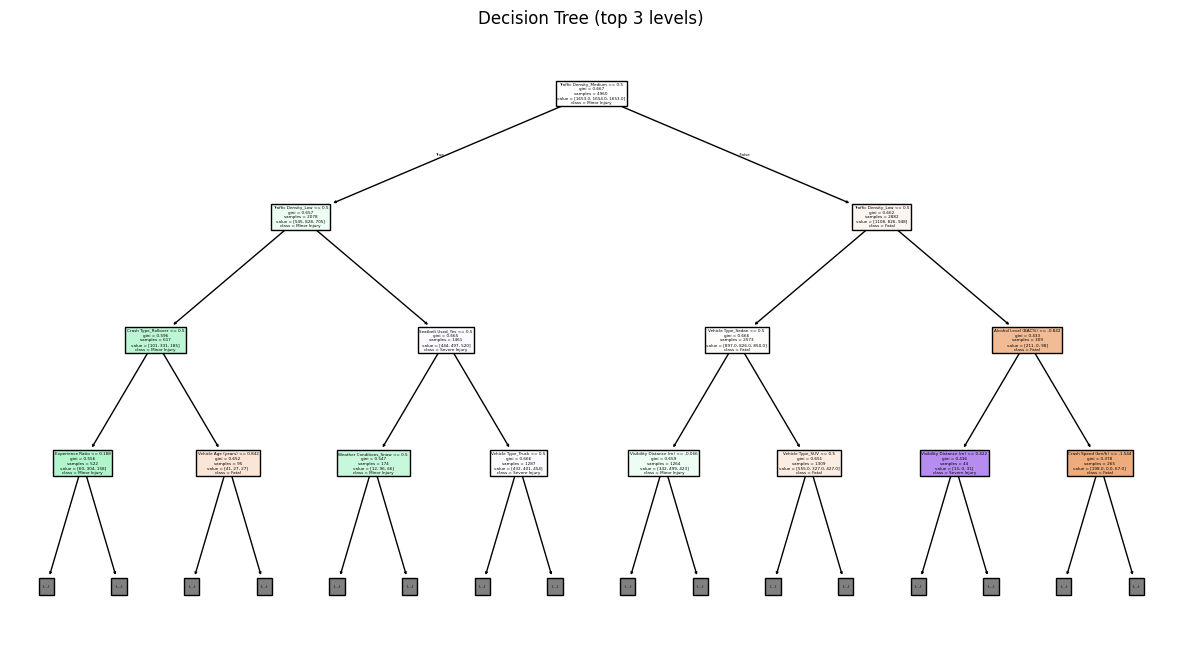

In [23]:
# ── Visualise the pruned tree ──
# With limited max_depth the tree remains interpretable
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plot_tree(dt, filled=True, feature_names=X.columns,
          class_names=[str(c) for c in le_target.classes_], max_depth=3)
plt.title('Decision Tree (top 3 levels)')
plt.show()

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    params, cv=5)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.6225806451612902


In [45]:
train_acc_dt = dt.score(X_train, y_train)
val_acc_dt = dt.score(X_val, y_val)
print(train_acc_dt)
print(val_acc_dt)

1.0
0.6305925030229746


In [24]:
# ── 5-fold Cross-Validation for Decision Tree ──
from sklearn.model_selection import cross_val_score

cv_f1_dt = cross_val_score(dt, X, y, cv=5, scoring='f1_weighted')
print('===== DECISION TREE CROSS-VALIDATION =====')
print('F1 per fold :', cv_f1_dt.round(4))
print('Mean F1     :', cv_f1_dt.mean().round(4))

===== DECISION TREE CROSS-VALIDATION =====
F1 per fold : [0.6183 0.6673 0.7017 0.6864 0.7119]
Mean F1     : 0.6771


# 2.3 Random Forest

In [25]:
# ── Baseline Random Forest ──
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

print('--- Baseline Random Forest ---')
print('Train Accuracy     :', round(rf_base.score(X_train, y_train), 4))
print('Validation Accuracy:', round(rf_base.score(X_val, y_val), 4))

--- Baseline Random Forest ---
Train Accuracy     : 1.0
Validation Accuracy: 0.8513


In [26]:
# ── Hyperparameter tuning with GridSearchCV ──
# n_estimators: number of trees (more → more stable, but slower)
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [3, 5, 10],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf' : [5, 10, 15],
    'max_features'     : ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print('Best params :', grid_rf.best_params_)
print('Best CV F1  :', round(grid_rf.best_score_, 4))

Best params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1  : 0.7408


In [27]:
# ── Evaluate the tuned Random Forest ──
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_val)

print('===== RANDOM FOREST VALIDATION PERFORMANCE =====')
print(f'Accuracy  : {accuracy_score(y_val, y_pred_rf):.4f}')
print(f'Precision : {precision_score(y_val, y_pred_rf, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_val, y_pred_rf, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_val, y_pred_rf, average="weighted"):.4f}')
print('\nDetailed Report:')
print(classification_report(y_val, y_pred_rf))

print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_rf))

===== RANDOM FOREST VALIDATION PERFORMANCE =====
Accuracy  : 0.7624
Precision : 0.7625
Recall    : 0.7624
F1 Score  : 0.7574

Detailed Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       552
           1       0.68      0.76      0.72       551
           2       0.76      0.59      0.67       551

    accuracy                           0.76      1654
   macro avg       0.76      0.76      0.76      1654
weighted avg       0.76      0.76      0.76      1654

Confusion Matrix:
[[514  23  15]
 [ 43 421  87]
 [ 54 171 326]]


In [28]:
# ── Overfitting check ──
train_acc_rf = best_rf.score(X_train, y_train)
val_acc_rf   = best_rf.score(X_val, y_val)
print('Train Accuracy     :', round(train_acc_rf, 4))
print('Validation Accuracy:', round(val_acc_rf, 4))
print('Gap                :', round(train_acc_rf - val_acc_rf, 4))

Train Accuracy     : 0.9399
Validation Accuracy: 0.7624
Gap                : 0.1775


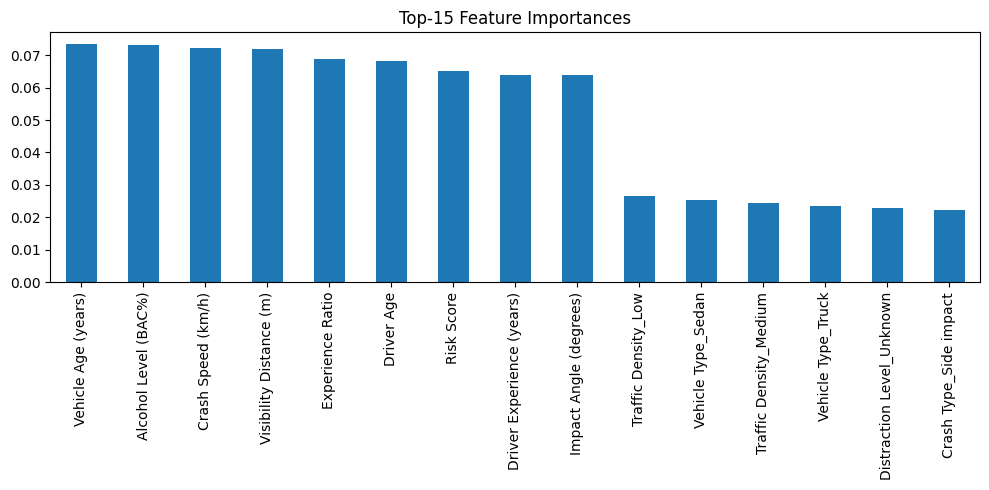

In [29]:
# ── Feature importance ──
# Shows which features the Random Forest found most useful for splitting
import matplotlib.pyplot as plt

feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(15).plot(
    kind='bar', figsize=(10, 5), title='Top-15 Feature Importances')
plt.tight_layout()
plt.show()

In [30]:
# ── 5-fold Cross-Validation for Random Forest ──
from sklearn.model_selection import cross_val_score

cv_f1_rf = cross_val_score(best_rf, X, y, cv=5, scoring='f1_weighted')
print('===== RANDOM FOREST CROSS-VALIDATION =====')
print('F1 per fold :', cv_f1_rf.round(4))
print('Mean F1     :', cv_f1_rf.mean().round(4))

===== RANDOM FOREST CROSS-VALIDATION =====
F1 per fold : [0.6025 0.7112 0.8354 0.8273 0.8308]
Mean F1     : 0.7614


# 2.4 Logistic Regression

In [31]:
# ── Re-scale features for Logistic Regression ──
from sklearn.preprocessing import StandardScaler

lr_scaler = StandardScaler()
scaled_X_train = lr_scaler.fit_transform(X_train)
scaled_X_val   = lr_scaler.transform(X_val)
scaled_X_test  = lr_scaler.transform(X_test)

In [32]:
# ── Train Logistic Regression ──
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(scaled_X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

===== LOGISTIC REGRESSION VALIDATION PERFORMANCE =====
Accuracy  : 0.5502
Precision : 0.5386
Recall    : 0.5502
F1 Score  : 0.5407

Detailed Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64       552
           1       0.56      0.64      0.60       551
           2       0.44      0.33      0.38       551

    accuracy                           0.55      1654
   macro avg       0.54      0.55      0.54      1654
weighted avg       0.54      0.55      0.54      1654



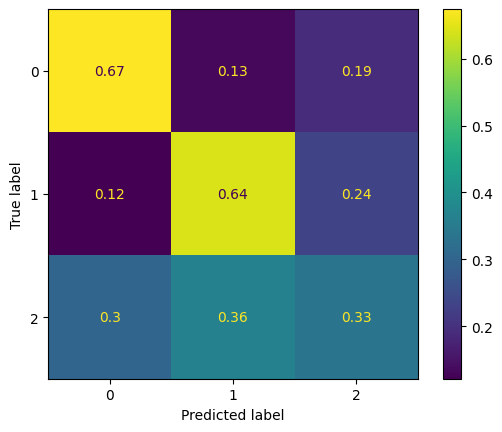

In [33]:
# ── Evaluate Logistic Regression on validation set ──
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

y_pred_lr = log_model.predict(scaled_X_val)

print('===== LOGISTIC REGRESSION VALIDATION PERFORMANCE =====')
print(f'Accuracy  : {accuracy_score(y_val, y_pred_lr):.4f}')
print(f'Precision : {precision_score(y_val, y_pred_lr, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_val, y_pred_lr, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_val, y_pred_lr, average="weighted"):.4f}')
print('\nDetailed Report:')
print(classification_report(y_val, y_pred_lr))

# Normalised confusion matrix (row = true, col = predicted)
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr, normalize='true')

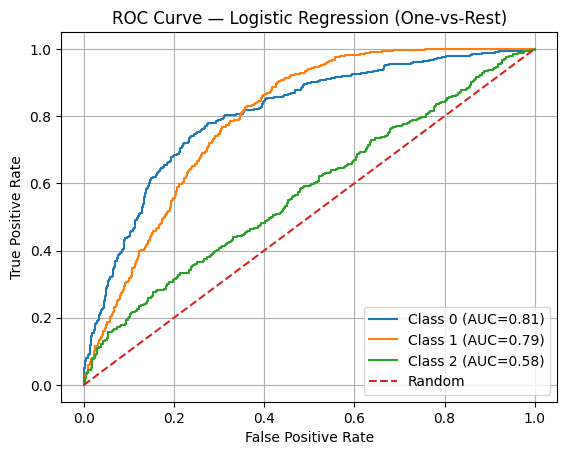

Overall AUC (OvR): 0.7254


In [34]:
# ── ROC Curve for Multiclass Logistic Regression (One-vs-Rest) ──
# For multiclass problems we plot one ROC curve per class using OvR binarisation
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_lr  = log_model.predict_proba(scaled_X_val)
classes_lr = log_model.classes_
y_val_bin  = label_binarize(y_val, classes=classes_lr)

plt.figure()
for i, cls in enumerate(classes_lr):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob_lr[:, i])
    auc_i = roc_auc_score(y_val_bin[:, i], y_prob_lr[:, i])
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC={auc_i:.2f})')

plt.plot([0, 1], [0, 1], '--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (One-vs-Rest)')
plt.legend()
plt.grid()
plt.show()

overall_auc = roc_auc_score(y_val, y_prob_lr, multi_class='ovr')
print('Overall AUC (OvR):', round(overall_auc, 4))

In [35]:
# ── 5-fold Cross-Validation for Logistic Regression ──
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Wrap scaler + model in a pipeline so CV scales each fold independently
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
cv_f1_lr = cross_val_score(lr_pipeline, X, y, cv=5, scoring='f1_weighted')
print('===== LOGISTIC REGRESSION CROSS-VALIDATION =====')
print('F1 per fold :', cv_f1_lr.round(4))
print('Mean F1     :', cv_f1_lr.mean().round(4))

===== LOGISTIC REGRESSION CROSS-VALIDATION =====
F1 per fold : [0.4345 0.5373 0.5699 0.555  0.5627]
Mean F1     : 0.5319


# 2.5 Naive Bayes

**Why Gaussian Naive Bayes?**
- **Gaussian NB** → suited for continuous numeric features (our case)
- Multinomial NB → for count data (e.g. word frequencies in text)
- Bernoulli NB   → for binary (0/1) features only

In [36]:
# ── Train Gaussian Naive Bayes ──
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

===== NAIVE BAYES VALIDATION PERFORMANCE =====
Accuracy  : 0.4921
Precision : 0.5202
Recall    : 0.4921
F1 Score  : 0.4933

Detailed Report:
              precision    recall  f1-score   support

           0       0.63      0.39      0.48       552
           1       0.54      0.56      0.55       551
           2       0.39      0.53      0.45       551

    accuracy                           0.49      1654
   macro avg       0.52      0.49      0.49      1654
weighted avg       0.52      0.49      0.49      1654



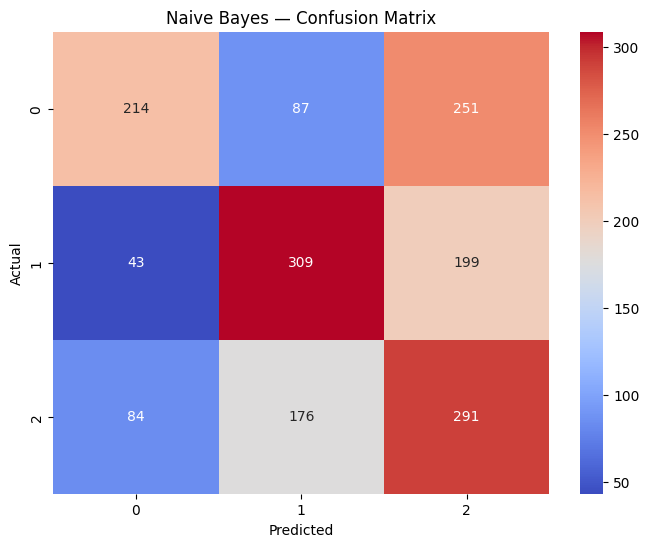

In [37]:
# ── Evaluate Naive Bayes on validation set ──
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_nb = nb_model.predict(X_val)

print('===== NAIVE BAYES VALIDATION PERFORMANCE =====')
print(f'Accuracy  : {accuracy_score(y_val, y_pred_nb):.4f}')
print(f'Precision : {precision_score(y_val, y_pred_nb, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_val, y_pred_nb, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_val, y_pred_nb, average="weighted"):.4f}')
print('\nDetailed Report:')
print(classification_report(y_val, y_pred_nb))

# Confusion matrix heatmap
cm_nb = confusion_matrix(y_val, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes — Confusion Matrix')
plt.show()

In [38]:
# ── 5-fold Cross-Validation for Naive Bayes ──
from sklearn.model_selection import cross_val_score

cv_f1_nb = cross_val_score(GaussianNB(), X, y, cv=5, scoring='f1_weighted')
print('===== NAIVE BAYES CROSS-VALIDATION =====')
print('F1 per fold :', cv_f1_nb.round(4))
print('Mean F1     :', cv_f1_nb.mean().round(4))

===== NAIVE BAYES CROSS-VALIDATION =====
F1 per fold : [0.3703 0.4279 0.4967 0.4893 0.4705]
Mean F1     : 0.451


# 3 Conclusion

In [39]:
# ── Validation accuracy comparison across all models ──
# All models are evaluated on the same held-out validation set for fairness
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

model_results = [
    ('KNN',                 knn,       X_val,       y_val),
    ('Decision Tree',       dt,        X_val,       y_val),
    ('Random Forest',       best_rf,   X_val,       y_val),
    ('Logistic Regression', log_model, scaled_X_val, y_val),
    ('Naive Bayes',         nb_model,  X_val,       y_val),
]

rows = []
for name, mdl, Xv, yv in model_results:
    preds = mdl.predict(Xv)
    rows.append({
        'Model'       : name,
        'Val Accuracy': round(accuracy_score(yv, preds), 4),
        'Val F1 (w)'  : round(f1_score(yv, preds, average='weighted'), 4),
    })

df_val = (pd.DataFrame(rows)
            .sort_values('Val F1 (w)', ascending=False)
            .reset_index(drop=True))
print('=' * 50)
print('       VALIDATION PERFORMANCE COMPARISON')
print('=' * 50)
print(df_val.to_string(index=False))

       VALIDATION PERFORMANCE COMPARISON
              Model  Val Accuracy  Val F1 (w)
      Random Forest        0.7624      0.7574
                KNN        0.7346      0.7204
      Decision Tree        0.6306      0.6274
Logistic Regression        0.5502      0.5407
        Naive Bayes        0.4921      0.4933


In [40]:
# ── Test accuracy comparison across all models ──
# Final evaluation on the unseen test set (used once, after model selection)
rows_test = []
for name, mdl, Xt, yt in [
    ('KNN',                 knn,       X_test,       y_test),
    ('Decision Tree',       dt,        X_test,       y_test),
    ('Random Forest',       best_rf,   X_test,       y_test),
    ('Logistic Regression', log_model, scaled_X_test, y_test),
    ('Naive Bayes',         nb_model,  X_test,       y_test),
]:
    preds = mdl.predict(Xt)
    rows_test.append({
        'Model'        : name,
        'Test Accuracy': round(accuracy_score(y_test, preds), 4),
        'Test F1 (w)'  : round(f1_score(y_test, preds, average='weighted'), 4),
    })

df_test = (pd.DataFrame(rows_test)
             .sort_values('Test F1 (w)', ascending=False)
             .reset_index(drop=True))
print('=' * 50)
print('         TEST PERFORMANCE COMPARISON')
print('=' * 50)
print(df_test.to_string(index=False))

         TEST PERFORMANCE COMPARISON
              Model  Test Accuracy  Test F1 (w)
      Random Forest         0.7557       0.7500
                KNN         0.7062       0.6881
      Decision Tree         0.6324       0.6281
Logistic Regression         0.5326       0.5231
        Naive Bayes         0.4885       0.4886


**Model Comparison Summary**

Random Forest achieved the highest validation and test F1-scores by leveraging ensemble averaging across many decorrelated trees, which effectively captures non-linear feature interactions that simpler models cannot.

KNN showed moderate performance — local similarity patterns exist in the data, but its distance metric struggles in high-dimensional spaces.

Decision Tree accuracy was lower, likely due to residual variance that ensemble methods mitigate. Naive Bayes performed poorly because the feature independence assumption is strongly violated here. Logistic Regression was limited by its linear decision boundary on an inherently non-linear dataset.

Overall, the results confirm that **Random Forest** is the most suitable model for this problem, offering the best balance of accuracy, robustness, and interpretability (via feature importances).

In [41]:
# Combine train + val back into full labeled data
import numpy as np

X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)

# Retrain best model (Random Forest) on full data
best_rf.fit(X_full, y_full)

print("Model retrained on full dataset.")
print("Full dataset size:", X_full.shape)

Model retrained on full dataset.
Full dataset size: (6614, 32)


In [42]:
X_test_array = X_test.values  # convert to numpy
test_pred = best_rf.predict(X_test_array)
test_acc = accuracy_score(y_test, test_pred)
print(f"RF Test Accuracy (after retraining on full data): {test_acc:.4f}")

RF Test Accuracy (after retraining on full data): 0.7739
